In [8]:
import os
import sys

# Define a extensão correta de acordo com o sistema operacional
extensao = ".exe" if sys.platform == "win32" else ""
nome_executavel = f"generator{extensao}"

print(f"Compilando o código C++ para {nome_executavel}...")
compile_cmd = f"g++ generator.cpp -o {nome_executavel}"
resultado = os.system(compile_cmd)

if resultado == 0:
    print("Compilação concluída com sucesso!")
else:
    print("Erro durante a compilação. Certifique-se de que o g++ está configurado no seu PATH.")

Compilando o código C++ para generator...
Compilação concluída com sucesso!


In [9]:
import subprocess
import sys
import re

def executar_e_parsear(vertices, is_dense, seed):
    extensao = ".exe" if sys.platform == "win32" else ""
    cmd_executavel = f"./generator{extensao}" if sys.platform != "win32" else f"generator{extensao}"
    
    argumentos = [cmd_executavel, str(vertices), str(is_dense), str(seed)]
    resultado = subprocess.run(argumentos, capture_output=True, text=True, shell=(sys.platform == "win32"))
    output = resultado.stdout
    
    if not output.strip():
        print("AVISO: O executável C++ retornou uma saída vazia. Verifique os parâmetros.")
        return {}, {}

    grafos = {"Original": [], "Kruskal": [], "Prim": []}
    tempos = {"Kruskal": 0.0, "Prim": 0.0}
    contexto_atual = None
    
    for linha in output.splitlines():
        linha_limpa = linha.strip()
        if not linha_limpa: continue
            
        if "Generated Connected Graph" in linha_limpa:
            contexto_atual = "Original"
            continue
        elif "Kruskal Minimum Spanning Tree" in linha_limpa:
            contexto_atual = "Kruskal"
            continue
        elif "Prim Minimum Spanning Tree" in linha_limpa:
            contexto_atual = "Prim"
            continue
            
        # Agora capturamos o tempo e associamos ao algoritmo correto
        if "Execution time" in linha_limpa and contexto_atual in ["Kruskal", "Prim"]:
            match = re.search(r'Execution time:\s*([0-9.]+)', linha_limpa)
            if match:
                tempos[contexto_atual] = float(match.group(1))
            continue
            
        if contexto_atual and re.match(r'^[A-Z]\s*\|', linha_limpa):
            valores_linha = [int(n) for n in re.findall(r'\d+', linha_limpa)]
            if valores_linha:
                grafos[contexto_atual].append(valores_linha)
                
    return grafos, tempos

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def plotar_resultados(dados_grafos, tempos, vertices, subtitulo_tipo):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    algoritmos = ["Original", "Kruskal", "Prim"]
    
    pos_fixa = None
    
    for ax, chave in zip(axes, algoritmos):
        matriz = dados_grafos.get(chave, [])
        
        if not matriz or len(matriz) != vertices:
            ax.text(0.5, 0.5, f"Dados de [{chave}]\nnão encontrados ou incompletos.", 
                    ha='center', va='center', color='red', fontsize=11)
            ax.axis('off')
            continue
            
        matriz_np = np.array(matriz)
        G = nx.from_numpy_array(matriz_np)
        
        mapeamento_letras = {i: chr(ord('A') + i) for i in range(vertices)}
        G = nx.relabel_nodes(G, mapeamento_letras)
        
        if pos_fixa is None:
            pos_fixa = nx.spring_layout(G, seed=42)
            
        # Adiciona o tempo de execução no título, se for Kruskal ou Prim
        if chave in tempos:
            titulo = f"{subtitulo_tipo} - {chave}\nTempo: {tempos[chave]:.4f} ms"
        else:
            titulo = f"{subtitulo_tipo} - {chave}"
            
        ax.set_title(titulo, fontsize=13, fontweight='bold')
        
        arestas_ativas = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] > 0]
        
        nx.draw_networkx_nodes(G, pos_fixa, ax=ax, node_color='lightgreen', node_size=500, edgecolors='black')
        nx.draw_networkx_labels(G, pos_fixa, ax=ax, font_size=10, font_weight='bold')
        nx.draw_networkx_edges(G, pos_fixa, ax=ax, edgelist=arestas_ativas, width=2.5, edge_color='teal')
        
        pesos_arestas = {(u, v): d['weight'] for u, v, d in G.edges(data=True) if d['weight'] > 0}
        nx.draw_networkx_edge_labels(G, pos_fixa, edge_labels=pesos_arestas, ax=ax, font_size=9)
        
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

In [17]:
# Modifique os tamanhos e sementes conforme necessário
valores_vertices = [i for i in range(2, 27)]
sementes = [c for c in range(100)]

# Estrutura para armazenar os tempos e plotar o gráfico no final
tempos_historico = {
    "Esparso": {"Kruskal": {v: [] for v in valores_vertices}, "Prim": {v: [] for v in valores_vertices}},
    "Denso": {"Kruskal": {v: [] for v in valores_vertices}, "Prim": {v: [] for v in valores_vertices}}
}

for v in valores_vertices:
    for s in sementes:
        print(f"\n" + "="*70)
        print(f"PROCESSANDO: {v} VÉRTICES | SEED CONFIGURADA: {s}")
        print("="*70)
        
        # Execução e plot para a variação Esparsa
        print("\n-> Renderizando Estrutura Esparsa...")
        dados_esparso, tempos_esparso = executar_e_parsear(v, 0, s)
        #plotar_resultados(dados_esparso, tempos_esparso, v, "Grafo Esparso")
        
        # Guardando tempos
        if tempos_esparso:
            tempos_historico["Esparso"]["Kruskal"][v].append(tempos_esparso["Kruskal"])
            tempos_historico["Esparso"]["Prim"][v].append(tempos_esparso["Prim"])
        
        # Execução e plot para a variação Densa
        print("\n-> Renderizando Estrutura Densa...")
        dados_denso, tempos_denso = executar_e_parsear(v, 1, s)
        #plotar_resultados(dados_denso, tempos_denso, v, "Grafo Denso")
        
        # Guardando tempos
        if tempos_denso:
            tempos_historico["Denso"]["Kruskal"][v].append(tempos_denso["Kruskal"])
            tempos_historico["Denso"]["Prim"][v].append(tempos_denso["Prim"])


PROCESSANDO: 2 VÉRTICES | SEED CONFIGURADA: 0

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 2 VÉRTICES | SEED CONFIGURADA: 1

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 2 VÉRTICES | SEED CONFIGURADA: 2

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 2 VÉRTICES | SEED CONFIGURADA: 3

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 2 VÉRTICES | SEED CONFIGURADA: 4

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 2 VÉRTICES | SEED CONFIGURADA: 5

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 2 VÉRTICES | SEED CONFIGURADA: 6

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 2 VÉRTICES | SEED CONFIGURADA: 7

-> Renderizando Estrutura Esparsa...

-> Renderizando Estrutura Densa...

PROCESSANDO: 2 VÉRTICES | SEED 

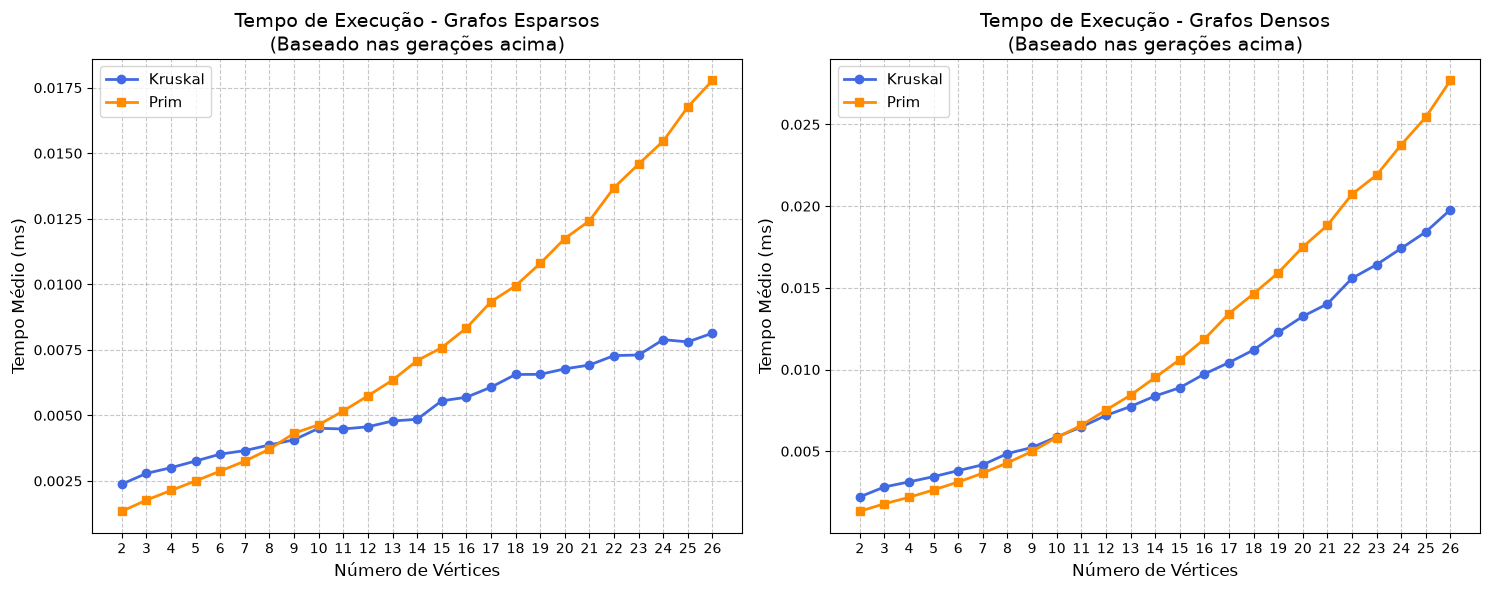

In [18]:
import numpy as np

# Calculando a média dos tempos agrupados por vértice
medias_esp_kru = [np.mean(tempos_historico["Esparso"]["Kruskal"][v]) for v in valores_vertices]
medias_esp_pri = [np.mean(tempos_historico["Esparso"]["Prim"][v]) for v in valores_vertices]
medias_den_kru = [np.mean(tempos_historico["Denso"]["Kruskal"][v]) for v in valores_vertices]
medias_den_pri = [np.mean(tempos_historico["Denso"]["Prim"][v]) for v in valores_vertices]

# Plotando os resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Grafos Esparsos
ax1.plot(valores_vertices, medias_esp_kru, label='Kruskal', marker='o', color='royalblue', linewidth=2)
ax1.plot(valores_vertices, medias_esp_pri, label='Prim', marker='s', color='darkorange', linewidth=2)
ax1.set_title('Tempo de Execução - Grafos Esparsos\n(Baseado nas gerações acima)', fontsize=14)
ax1.set_xlabel('Número de Vértices', fontsize=12)
ax1.set_ylabel('Tempo Médio (ms)', fontsize=12)
ax1.set_xticks(valores_vertices)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Grafos Densos
ax2.plot(valores_vertices, medias_den_kru, label='Kruskal', marker='o', color='royalblue', linewidth=2)
ax2.plot(valores_vertices, medias_den_pri, label='Prim', marker='s', color='darkorange', linewidth=2)
ax2.set_title('Tempo de Execução - Grafos Densos\n(Baseado nas gerações acima)', fontsize=14)
ax2.set_xlabel('Número de Vértices', fontsize=12)
ax2.set_ylabel('Tempo Médio (ms)', fontsize=12)
ax2.set_xticks(valores_vertices)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()